# **Detecção de forma OpenCV**

### **Calculando o centro de uma forma**

Para calcular o centro de um contorno usando python+opencv devemos:

Passos:

1. Converter a imagem em escala de cinza.

2. Desfocar para reduzir o ruído de alta frequência e para tornar nosso processo de detecção de contorno mais preciso.

3. Binarizar a imagem.

 Normalmente, a detecção e o limiar de borda são usados para esse processo.




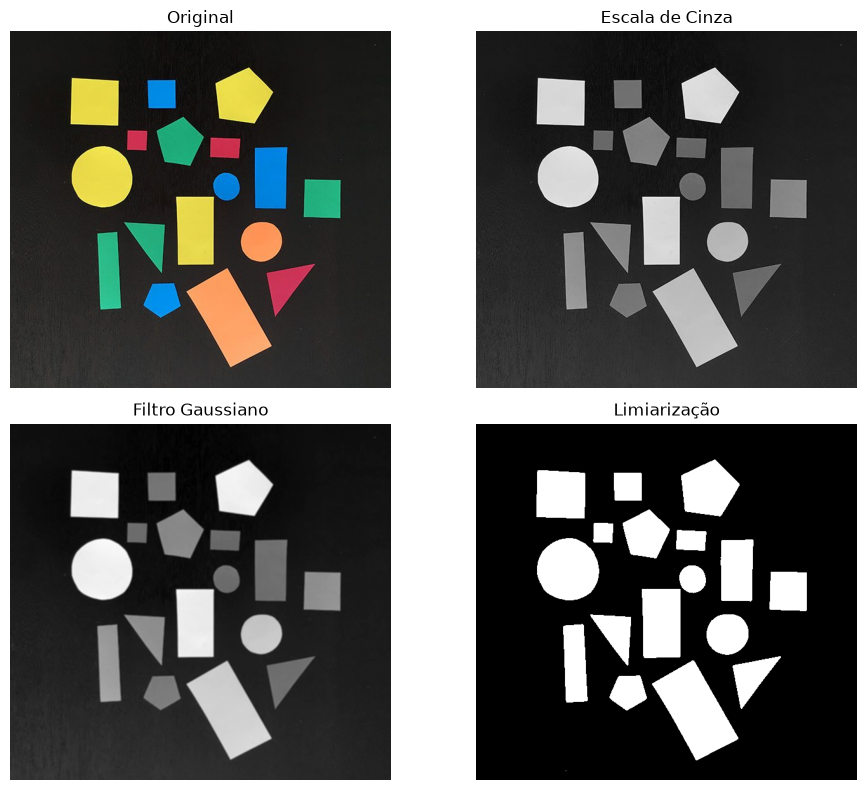

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("image/shapes_and_colors.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)

ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax0, ax1, ax2, ax3 = axes.ravel()

ax0.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax0.set_title("Original")
ax0.axis("off")

ax1.imshow(gray, cmap = 'gray')
ax1.set_title("Escala de Cinza")
ax1.axis("off")

ax2.imshow(gaussian, cmap = 'gray')
ax2.set_title("Filtro Gaussiano")
ax2.axis("off")

ax3.imshow(threshold, cmap = 'gray')
ax3.set_title("Limiarização")
ax3.axis("off")
plt.tight_layout()

O próximo passo é encontrar a localização dessas regiões brancas usando a detecção de contorno

(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

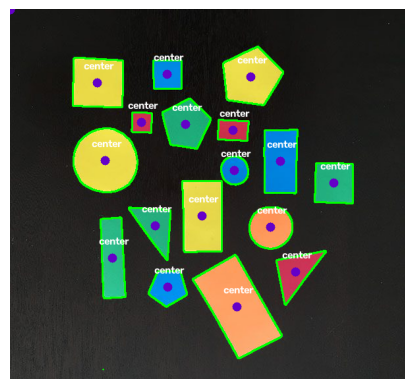

In [2]:
contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for c in contornos:
    # compute the center of the contour
    M = cv2.moments(c)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        
    else:
        # Se m00 for zero, define uma coordenada padrão (ou ignora o contorno)
        cX, cY = 0, 0

    #draw the contour and center of the shape on the image
    cv2.drawContours(image, [c], -1, (0,255, 0), 2)
    cv2.circle(image, (cX,cY), 7, (200, 0, 100), -1)
    cv2.putText(image, "center", (cX -20, cY -20),cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)


    # show the image
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')


### **Detecção de formas** 

**detect(c)** é uma função responsável por analisar um contorno c e determinar qual forma geométrica ele representa. 

Primeiramente, a função calcula o perímetro do contorno, depois simplifica esse contorno utilizando approxPolyDP() e verifica quantos vértices existem nessa aproximação. 

A partir da quantidade de vértices, ela classifica a forma e retorna seu nome, como "triangle", "square" ou "circle".

---
**cv2.arcLength(c, True)**: é uma função da biblioteca OpenCV utilizada para calcular o comprimento de um contorno, isto é, seu perímetro. 

O primeiro parâmetro é o contorno que queremos medir. O segundo parâmetro informa que o contorno deve ser considerado fechado, isso significa que o último ponto do contorno está conectado ao primeiro. 

---
**cv2.approxPolyDP(c, 0.04 * peri, True)**: é uma função utilizada para aproximar e simplificar um contorno. 

Um contorno real pode possuir muitos pontos, mesmo quando representa uma forma simples. Essa função tenta representar o contorno usando apenas os pontos mais importantes, formando uma aproximação poligonal. 

O primeiro parâmetro é o contorno original; o segundo, 0.04 * peri é o valor de tolerância da aproximação, chamado de **epsilon**; e o terceiro indica novamente que o contorno é fechado.

Uma atenção especial para o **epsilon**, pois esse valor determina o quanto o approxPolyDP() pode simplificar o contorno. Quanto maior o epsilon, maior pode ser a diferença entre o contorno original e a aproximação, fazendo com que menos pontos sejam utilizados. Quanto menor o epsilon, mais pontos serão preservados.

---

**cv2.boundingRect(approx):** é uma função que encontra o menor retângulo alinhado aos eixos da imagem capaz de envolver completamente o contorno fornecido. Ela retorna quatro valores: x, y, w e h. x e y representam a posição do canto superior esquerdo desse retângulo, enquanto w representa sua largura e h sua altura.

No tutorial essa função é utilizada apenas quando o contorno possui quatro vértices, porque ela conseguirá definir se a figura de quatro lados é mais parecida com um quadrado ou com um retângulo

ar = w / float(h): calcula a proporção entre a largura e a altura do retângulo que envolve a forma. Essa proporção é chamada de aspect ratio. Se w e h forem aproximadamente iguais, o resultado será próximo de 1, indicando uma forma aproximadamente quadrada. Se a largura for muito maior ou menor que a altura, o resultado ficará diferente de 1, indicando um retângulo.

shape = "square" if ar >= 0.95 and ar <= 1.05 else "rectangle": essa linha utiliza o valor do aspect ratio para diferenciar quadrados de retângulos. Se ar estiver entre 0.95 e 1.05, a forma é considerada um quadrado. Essa margem existe porque, em uma imagem real, pequenas distorções podem fazer com que um quadrado não apresente exatamente ar = 1. Caso o valor esteja fora desse intervalo, a forma é considerada um retângulo.

In [ ]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        else:
            shape = "circle"

        return shape



Antes de encontrar os contornos, é necessário realizar um pré-processamento da imagem para facilitar a identificação das formas.

Primeiramente, a imagem é redimensionada utilizando um fator de escala. Esse redimensionamento reduz o tamanho da imagem, tornando o processamento mais rápido, mas mantendo sua proporção original.

Em seguida, a imagem, que está originalmente no formato BGR utilizado pelo OpenCV, é convertida para a escala de tons de cinza. Essa conversão reduz a quantidade de informações da imagem, fazendo com que cada pixel seja representado apenas por um valor de intensidade, o que facilita as etapas seguintes.

Depois, é aplicado um desfoque gaussiano utilizando **cv2.GaussianBlur()**. Essa etapa tem como objetivo suavizar a imagem e reduzir pequenos ruídos que poderiam interferir na identificação das formas.

Na sequência, é aplicado um limiar utilizando **cv2.threshold()**. Essa operação transforma a imagem em uma representação binária, separando os pixels de acordo com um determinado valor de intensidade. Dessa forma, as regiões de interesse ficam destacadas, facilitando a identificação das formas.

Após esse pré-processamento, é utilizada a função **cv2.findContours()** para encontrar os contornos presentes na imagem binária. Cada contorno representa a borda de uma região identificada na imagem.

Na estrutura **for**, começamos a percorrer individualmente cada um dos contornos encontrados. Para cada contorno, são calculados seus momentos geométricos utilizando **cv2.moments()**. Esses momentos permitem calcular as coordenadas **(x, y)** do centroide da forma.

Em seguida, o contorno é enviado para o objeto **ShapeDetector**, que utiliza o método **detect()** para identificar a forma geométrica. Para isso, o contorno é simplificado utilizando **cv2.approxPolyDP()**, permitindo analisar a quantidade de vértices e classificar a forma como triângulo, quadrado, retângulo, pentágono ou círculo.

Como os contornos foram extraídos da imagem redimensionada, as coordenadas do centroide e os pontos do contorno também estão nessa mesma escala. Por isso, é necessário multiplicar essas coordenadas pelo fator **ratio**, fazendo com que elas correspondam novamente às dimensões da imagem original.

Depois dessa conversão, **cv2.drawContours()** é utilizado para desenhar o contorno na imagem original. Em seguida, **cv2.putText()** escreve o nome da forma próximo ao seu centroide.


**M = cv2.moments(c)**: cv2.moments() calcula os momentos geométricos do contorno c. Esses momentos são valores matemáticos que descrevem como a área do objeto está distribuída na imagem. Neste código, eles são utilizados principalmente para descobrir a posição do centroide do objeto. O resultado é armazenado na variável M, que contém diversos valores, entre eles m00, m10 e m01, que serão utilizados para calcular as coordenadas do centro.

(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

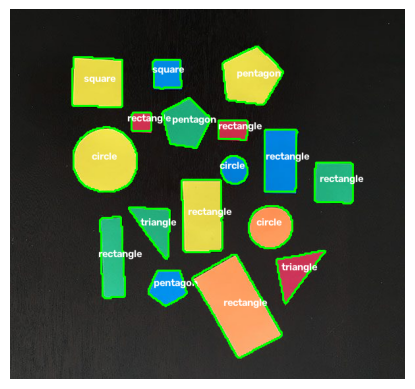

In [ ]:
image = cv2.imread("image/shapes_and_colors.jpg")

scale = 300 / image.shape[1]

new_width = int(image.shape[1] * scale)
new_height = int(image.shape[0] * scale)

resized = cv2.resize(image, (new_width, new_height))
ratio = 1 / scale

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)

ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

sd = ShapeDetector()

for c in contornos:

    M = cv2.moments(c)

    if M["m00"] != 0:

        # Centro na imagem REDUZIDA
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Identifica a forma
        shape = sd.detect(c)

        # Converte centro para a imagem ORIGINAL
        cX = int(cX * ratio)
        cY = int(cY * ratio)

        # Escala o contorno para a imagem original
        c_scaled = c.astype("float") * ratio
        c_scaled = c_scaled.astype("int")

        # Desenha contorno
        cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

        # Escreve o nome no centro
        cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255, 255, 255),2)

    # show the image
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')
